<div style="border-left:6px solid #b30338; padding:8px 16px;">

# MCDI505 — Análisis de Series de Tiempo
## Sesión 1 · Naturaleza de los datos temporales y autocorrelación

**Magíster en Ciencia de Datos · UNAB Online**  
**Duración estimada:** 90 min de trabajo guiado + 60 min de laboratorio autónomo

</div>

---

En esta sesión se estudia cómo **caracterizar** una serie de tiempo, **distinguirla** de una muestra aleatoria, **cuantificar** su estructura de dependencia mediante la función de autocorrelación y **justificar** por qué la inferencia estadística clásica falla en presencia de autocorrelación.

### Requisitos previos
Python intermedio (`numpy`, `pandas`, `matplotlib`), regresión lineal simple, nociones de esperanza, varianza y covarianza, y prueba de hipótesis.

### Cómo trabajar este notebook
1. **Ejecute las celdas en orden.** El notebook es autocontenido: no requiere descargar archivos externos ni conexión a internet.
2. Las celdas marcadas con 🧭 **Pausa analítica** contienen preguntas que debe responder *antes* de continuar. Escriba su respuesta en la celda de texto siguiente.
3. Las celdas marcadas con ✍️ **Su turno** contienen código incompleto que usted debe completar.
4. El §10 (Laboratorio) constituye el **entregable evaluado** de la semana.

### Reproducibilidad
Todos los procesos aleatorios usan una semilla fija (`SEMILLA = 505`). Si sus resultados numéricos difieren de los del enunciado, revise que no haya reejecutado celdas fuera de orden.

---
# 0. El problema que guía la sesión

> ### 📌 Caso: *Bodegaje y quiebres de stock*
>
> Usted es analista de datos en una plataforma de comercio electrónico. La **Gerencia Comercial** le envía dos series de demanda semanal de los últimos ~2,5 años (producto **A** y producto **B**) junto con este correo:
>
> *"Ambos productos vienen creciendo de forma sostenida. Ajustamos una recta de tendencia a cada serie y en los dos casos la pendiente resultó **estadísticamente significativa (p < 0,05)**. Solicitamos aumentar el inventario de ambos en 20% para el próximo trimestre."*
>
> Un aumento de inventario mal justificado inmoviliza capital; un quiebre de stock pierde ventas. **La decisión cuesta dinero en ambas direcciones.**
>
> ### ❓ Pregunta a responder al final de la sesión
> **¿La evidencia estadística presentada por la Gerencia respalda la decisión para *ambos* productos, para *uno* de ellos, o para *ninguno*? Fundamente.**

Antes de responder necesitamos construir cuatro herramientas conceptuales:

| Herramienta | Sección | Pregunta que responde |
|---|---|---|
| Proceso estocástico / realización | §2 | ¿Qué estamos observando realmente cuando vemos *una* serie? |
| Dependencia temporal | §3 | ¿Por qué el orden de los datos importa? |
| Autocorrelación (ACF / PACF) | §5 | ¿Cómo *medimos* esa dependencia? |
| Estacionariedad | §7 | ¿Bajo qué condiciones la medición es válida? |

Guarde la pregunta en mente: **todo lo que sigue existe para poder contestarla con rigor.**

---
# 1. Configuración del entorno

In [3]:
# --- Bibliotecas ---
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")   # silenciamos avisos de interpolacion de p-valores

# --- Reproducibilidad ---
SEMILLA = 505
rng = np.random.default_rng(SEMILLA)

# --- Estetica comun de los graficos ---
plt.rcParams.update({
    "figure.figsize": (11, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "font.size": 9,
    "lines.linewidth": 1.2,
})

print(f"Python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scipy        {scipy.__version__}")
print(f"statsmodels  {statsmodels.__version__}")
print("\nEntorno listo. Semilla global:", SEMILLA)

Python       3.12.7
numpy        2.4.3
pandas       2.3.3
scipy        1.17.1
statsmodels  0.14.6

Entorno listo. Semilla global: 505


In [4]:
# ---------------------------------------------------------------------------
# Generadores de procesos sinteticos: los usaremos durante toda la asignatura.
# Trabajar con procesos de los que CONOCEMOS la verdad es la unica forma de
# saber si un metodo de diagnostico funciona.
# ---------------------------------------------------------------------------

def ruido_blanco(n, sigma=1.0, m=1, rng=rng):
    '''Ruido blanco gaussiano: independiente, media 0, varianza constante.'''
    return rng.normal(0.0, sigma, size=(m, n))


def ar1(phi, n, sigma=1.0, m=1, rng=rng):
    '''AR(1):  X_t = phi * X_{t-1} + e_t.

    Si |phi| < 1 el proceso es estacionario y se inicializa en su distribucion
    estacionaria (evita el transiente inicial). Si |phi| >= 1 parte en 0.
    '''
    e = rng.normal(0.0, sigma, size=(m, n))
    x = np.empty((m, n))
    x[:, 0] = e[:, 0] / np.sqrt(1 - phi**2) if abs(phi) < 1 else 0.0
    for t in range(1, n):
        x[:, t] = phi * x[:, t - 1] + e[:, t]
    return x


def caminata_aleatoria(n, sigma=1.0, m=1, rng=rng):
    '''Random walk: X_t = X_{t-1} + e_t. Caso limite del AR(1) con phi = 1.'''
    return np.cumsum(rng.normal(0.0, sigma, size=(m, n)), axis=1)


def ma1(theta, n, sigma=1.0, m=1, rng=rng):
    '''MA(1):  X_t = e_t + theta * e_{t-1}. Memoria de un solo periodo.'''
    e = rng.normal(0.0, sigma, size=(m, n + 1))
    return e[:, 1:] + theta * e[:, :-1]


# Verificacion rapida de formas
for f, nombre in [(ruido_blanco, "ruido blanco"), (caminata_aleatoria, "caminata")]:
    assert f(50, m=3).shape == (3, 50), nombre
assert ar1(0.7, 50, m=3).shape == (3, 50)
assert ma1(0.6, 50, m=3).shape == (3, 50)
print("Generadores verificados ✔")

Generadores verificados ✔


---
# 2. ¿Qué observamos realmente? Proceso, ensamble y realización

En estadística clásica trabajamos con una **muestra** $x_1,\dots,x_n$ de una variable aleatoria $X$: si repitiéramos el experimento obtendríamos otra muestra del mismo tamaño, y con muchas repeticiones podríamos aproximar la distribución de $X$.

En series de tiempo el escenario es distinto y más incómodo:

| Concepto | Definición | Analogía |
|---|---|---|
| **Proceso estocástico** $\{X_t\}_{t\in T}$ | Colección de variables aleatorias indexadas por el tiempo. Es el *objeto teórico* que queremos entender. | La "receta" que genera la historia. |
| **Ensamble** | El conjunto de **todas** las trayectorias que el proceso podría haber generado. | Todos los universos paralelos. |
| **Realización** | **Una** trayectoria concreta, la que efectivamente observamos. | El universo en el que nos tocó vivir. |

> ### ⚠️ El problema fundacional
> Del ensamble **solo observamos una realización**, y de ella **un solo punto por instante de tiempo**. No podemos "repetir" el año 2024 mil veces para estimar $\mathbb{E}[X_{2024}]$.
>
> Entonces, ¿cómo estimamos algo? Reemplazamos el promedio *a través del ensamble* por el promedio *a lo largo del tiempo*. Esa sustitución solo es lícita si el proceso es **estacionario** y **ergódico**. Esta es la razón profunda por la que la estacionariedad (§7) es un requisito y no un tecnicismo.

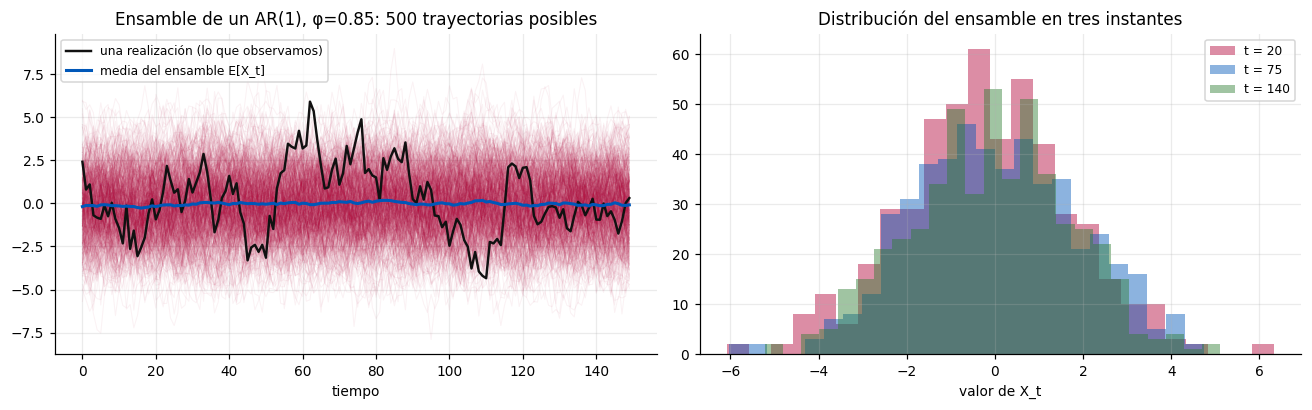

Media del ensamble en t=20 : -0.185   (teórica: 0)
Media del ensamble en t=140: -0.089   (teórica: 0)
Media TEMPORAL de UNA sola realización:  0.225
Desv. est. del ensamble en t=140:  1.789   (teórica:  1.898)


In [5]:
# Simulamos el ENSAMBLE de un AR(1): 300 realizaciones del MISMO proceso.
n, M, phi = 150, 500, 0.85
ensamble = ar1(phi, n, m=M, rng=np.random.default_rng(SEMILLA))
t = np.arange(n)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# --- Izquierda: el ensamble completo ---
axes[0].plot(t, ensamble.T, color="#b30338", alpha=0.05, lw=0.7)
axes[0].plot(t, ensamble[0], color="#111111", lw=1.6, label="una realización (lo que observamos)")
axes[0].plot(t, ensamble.mean(axis=0), color="#0057b8", lw=2.0, label="media del ensamble E[X_t]")
axes[0].set_title(f"Ensamble de un AR(1), φ={phi}: {M} trayectorias posibles")
axes[0].set_xlabel("tiempo"); axes[0].legend(fontsize=8)

# --- Derecha: distribucion en cortes de tiempo fijos ---
for corte, color in zip([20, 75, 140], ["#b30338", "#0057b8", "#2e7d32"]):
    axes[1].hist(ensamble[:, corte], bins=25, alpha=0.45, color=color, label=f"t = {corte}")
axes[1].set_title("Distribución del ensamble en tres instantes")
axes[1].set_xlabel("valor de X_t"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Media del ensamble en t=20 : {ensamble[:, 20].mean(): .3f}   (teórica: 0)")
print(f"Media del ensamble en t=140: {ensamble[:, 140].mean(): .3f}   (teórica: 0)")
print(f"Media TEMPORAL de UNA sola realización: {ensamble[0].mean(): .3f}")
print(f"Desv. est. del ensamble en t=140: {ensamble[:, 140].std(): .3f} "
      f"  (teórica: {1/np.sqrt(1-phi**2): .3f})")

🧭 **Pausa analítica**

1. Las tres distribuciones del panel derecho son prácticamente idénticas. ¿Qué propiedad del proceso está usted observando?
2. La media temporal de *una* realización se parece a la media del ensamble. ¿Qué supuesto adicional se necesita para que esto ocurra siempre?
3. Repita la simulación con `phi = 0.99` y con `caminata_aleatoria`. ¿Siguen coincidiendo las distribuciones en los distintos cortes de tiempo? ¿Qué implica eso para la estimación?

*Escriba su respuesta aquí (doble clic para editar):*

---

---
# 3. Independencia vs. dependencia temporal

La diferencia operativa entre una muestra aleatoria y una serie de tiempo es que en la primera el **orden es irrelevante** y en la segunda el **orden lo es todo**.

Compare dos experimentos:

- **Dado honesto:** el resultado en $t$ no dice nada sobre $t+1$. Es *ruido blanco*, la ausencia total de estructura.
- **Dado con memoria:** con probabilidad $p$ el dado repite el valor anterior; en caso contrario se lanza de nuevo. La distribución marginal sigue siendo uniforme sobre $\{1,\dots,6\}$ — un histograma **no** distingue ambos casos —, pero la *secuencia* es completamente distinta.

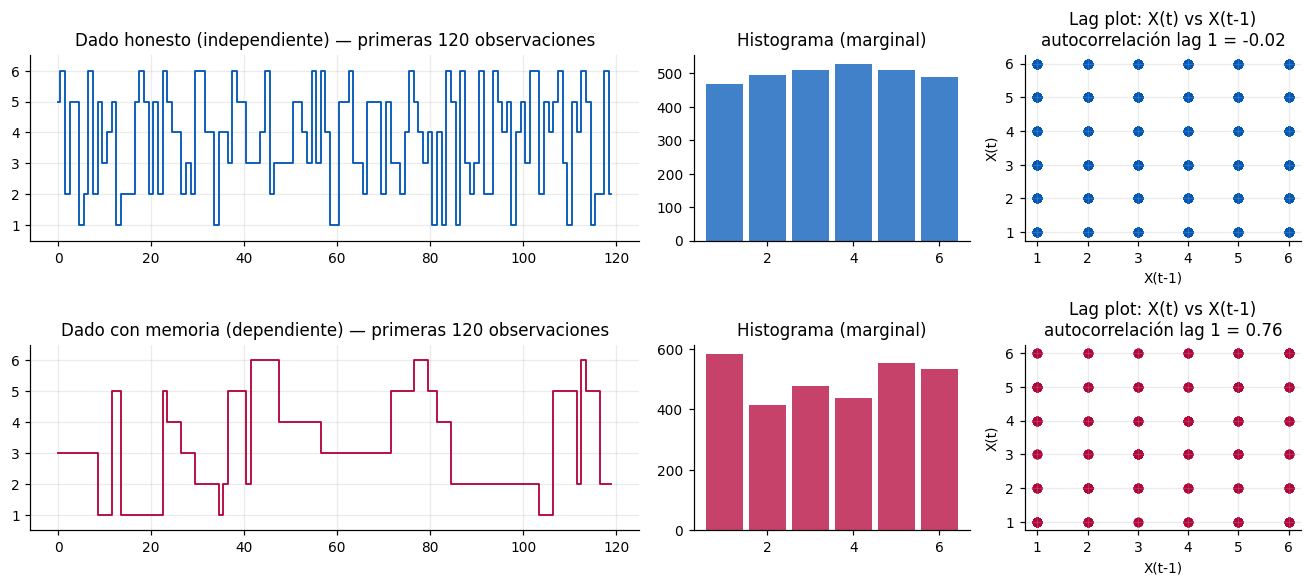

n = 3000 lanzamientos en cada caso
Media  — independiente: 3.53 | con memoria: 3.52   (teórica: 3.50)
Desv.  — independiente: 1.68 | con memoria: 1.77   (teórica: 1.71)

Los estadísticos MARGINALES coinciden: ambos dados son 'honestos' en el sentido
clásico. La diferencia vive por completo en el ORDEN de los resultados.

Detalle importante: la media de la serie DEPENDIENTE converge mucho más lento,
porque 3000 lanzamientos con memoria contienen bastante menos información que
3000 independientes. Este 'tamaño muestral efectivo' reducido es exactamente lo
que rompe los errores estándar en la §6.


In [6]:
def dado_independiente(n, rng=rng):
    return rng.integers(1, 7, size=n)


def dado_con_memoria(n, p_repetir=0.75, rng=rng):
    '''Cadena de Markov: con prob. p_repetir conserva el valor anterior.'''
    x = np.empty(n, dtype=int)
    x[0] = rng.integers(1, 7)
    for t in range(1, n):
        x[t] = x[t - 1] if rng.random() < p_repetir else rng.integers(1, 7)
    return x


g = np.random.default_rng(SEMILLA)
d_ind = dado_independiente(3000, g)
d_mem = dado_con_memoria(3000, 0.75, g)
VENTANA = 120   # solo para el gráfico de la secuencia

fig, axes = plt.subplots(2, 3, figsize=(12, 5.4),
                         gridspec_kw={"width_ratios": [2.2, 1, 1]})
for fila, (serie, nombre, color) in enumerate(
        [(d_ind, "Dado honesto (independiente)", "#0057b8"),
         (d_mem, "Dado con memoria (dependiente)", "#b30338")]):

    axes[fila, 0].step(np.arange(VENTANA), serie[:VENTANA], color=color, where="mid")
    axes[fila, 0].set_title(f"{nombre} — primeras {VENTANA} observaciones"); axes[fila, 0].set_ylim(0.5, 6.5)

    axes[fila, 1].hist(serie, bins=np.arange(0.5, 7.5), color=color, alpha=0.75, rwidth=0.85)
    axes[fila, 1].set_title("Histograma (marginal)"); axes[fila, 1].grid(False)

    axes[fila, 2].scatter(serie[:-1], serie[1:], alpha=0.35, s=28, color=color)
    r1 = acf(serie, nlags=1)[1]
    axes[fila, 2].set_title(f"Lag plot: X(t) vs X(t-1)\nautocorrelación lag 1 = {r1:.2f}")
    axes[fila, 2].set_xlabel("X(t-1)"); axes[fila, 2].set_ylabel("X(t)")

plt.tight_layout(); plt.show()

print(f"n = {len(d_ind)} lanzamientos en cada caso")
print(f"Media  — independiente: {d_ind.mean():.2f} | con memoria: {d_mem.mean():.2f}   (teórica: 3.50)")
print(f"Desv.  — independiente: {d_ind.std():.2f} | con memoria: {d_mem.std():.2f}   (teórica: 1.71)")
print("\nLos estadísticos MARGINALES coinciden: ambos dados son 'honestos' en el sentido")
print("clásico. La diferencia vive por completo en el ORDEN de los resultados.")
print("\nDetalle importante: la media de la serie DEPENDIENTE converge mucho más lento,")
print("porque 3000 lanzamientos con memoria contienen bastante menos información que")
print("3000 independientes. Este 'tamaño muestral efectivo' reducido es exactamente lo")
print("que rompe los errores estándar en la §6.")

> ### 💡 Idea central de la asignatura
> Un histograma, una media y una desviación estándar **descartan** información temporal. Toda la asignatura consiste en aprender a modelar precisamente aquello que esos resúmenes tiran a la basura.
>
> Y hay una buena noticia: **la dependencia es lo que hace posible el pronóstico**. Si los datos fueran verdaderamente independientes, la mejor predicción para mañana sería siempre la media histórica y no habría nada más que hacer.

---

---
# 4. Patrones visuales: el primer diagnóstico

Antes de cualquier modelo, **grafique**. La inspección visual orienta toda la estrategia de modelamiento posterior.

Usaremos series reales incluidas en `statsmodels` (no requieren descarga) más procesos simulados:

| Serie | Origen | Patrón dominante |
|---|---|---|
| CO₂ Mauna Loa | `sm.datasets.co2` | Tendencia + estacionalidad anual |
| Manchas solares | `sm.datasets.sunspots` | **Ciclo** (no estacionalidad) |
| Caudal del Nilo | `sm.datasets.nile` | Quiebre estructural (1899) |
| Caminata aleatoria | simulada | Deriva errática (*wandering*) |
| Ruido blanco | simulada | Ausencia de estructura |
| Varianza creciente | simulada | Heterocedasticidad (anticipa GARCH) |

In [7]:
# --- Carga de series reales empaquetadas con statsmodels (funciona sin internet) ---

def cargar_co2():
    s = sm.datasets.co2.load_pandas().data["co2"]
    # datos semanales con faltantes -> agregamos a mensual e interpolamos
    return s.resample("MS").mean().interpolate().rename("CO2 (ppm)")


def cargar_sunspots():
    d = sm.datasets.sunspots.load_pandas().data
    idx = pd.PeriodIndex(d["YEAR"].astype(int).astype(str), freq="Y").to_timestamp()
    return pd.Series(d["SUNACTIVITY"].to_numpy(), index=idx, name="Manchas solares")


def cargar_nile():
    d = sm.datasets.nile.load_pandas().data
    idx = pd.PeriodIndex(d["year"].astype(int).astype(str), freq="Y").to_timestamp()
    return pd.Series(d["volume"].to_numpy(), index=idx, name="Caudal del Nilo")


co2 = cargar_co2()
sunspots = cargar_sunspots()
nile = cargar_nile()

for s in (co2, sunspots, nile):
    print(f"{s.name:<18} n={len(s):>4}  desde {s.index.min().date()}  hasta {s.index.max().date()}")
co2.head()

CO2 (ppm)          n= 526  desde 1958-03-01  hasta 2001-12-01
Manchas solares    n= 309  desde 1700-01-01  hasta 2008-01-01
Caudal del Nilo    n= 100  desde 1871-01-01  hasta 1970-01-01


1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.529167
1958-07-01    315.625000
Freq: MS, Name: CO2 (ppm), dtype: float64

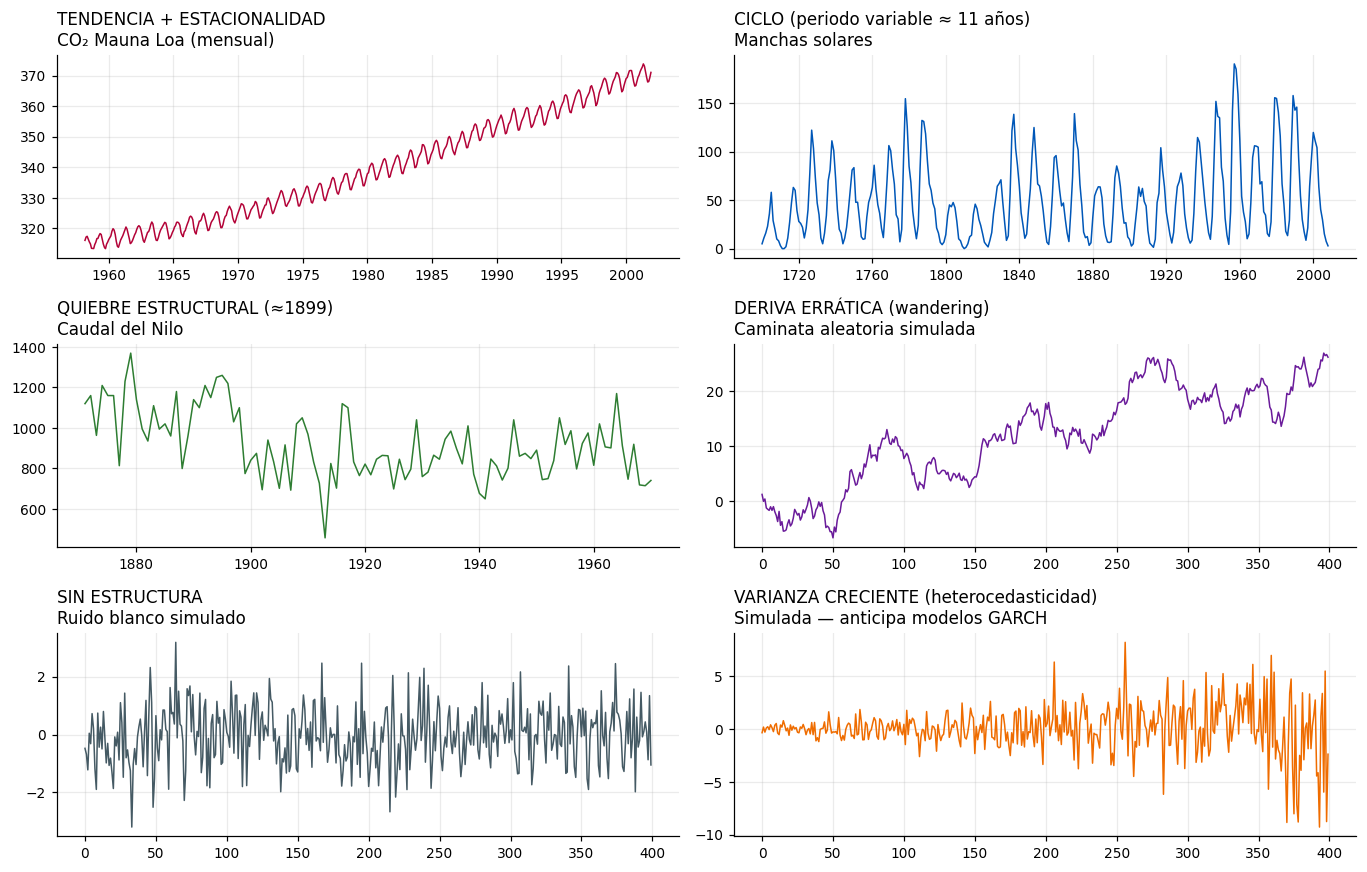

In [8]:
g = np.random.default_rng(SEMILLA)
n = 400
series_demo = [
    (co2.index, co2.to_numpy(), "TENDENCIA + ESTACIONALIDAD\nCO₂ Mauna Loa (mensual)", "#b30338"),
    (sunspots.index, sunspots.to_numpy(), "CICLO (periodo variable ≈ 11 años)\nManchas solares", "#0057b8"),
    (nile.index, nile.to_numpy(), "QUIEBRE ESTRUCTURAL (≈1899)\nCaudal del Nilo", "#2e7d32"),
    (np.arange(n), caminata_aleatoria(n, m=1, rng=g)[0], "DERIVA ERRÁTICA (wandering)\nCaminata aleatoria simulada", "#6a1b9a"),
    (np.arange(n), ruido_blanco(n, m=1, rng=g)[0], "SIN ESTRUCTURA\nRuido blanco simulado", "#455a64"),
    (np.arange(n), ruido_blanco(n, m=1, rng=g)[0] * np.linspace(0.3, 3.5, n),
     "VARIANZA CRECIENTE (heterocedasticidad)\nSimulada — anticipa modelos GARCH", "#ef6c00"),
]

fig, axes = plt.subplots(3, 2, figsize=(12.5, 8))
for ax, (x, y, titulo, color) in zip(axes.ravel(), series_demo):
    ax.plot(x, y, color=color, lw=1.0)
    ax.set_title(titulo, loc="left")
plt.tight_layout(); plt.show()

### Estacionalidad ≠ ciclo

Es la confusión más frecuente del curso, y tiene consecuencias directas sobre la elección del modelo.

| | **Estacionalidad** | **Ciclo** |
|---|---|---|
| Periodo | **Fijo y conocido** (12 meses, 7 días, 4 trimestres) | Variable, no conocido de antemano |
| Origen | Calendario, clima, convenciones humanas | Dinámica interna del sistema |
| Amplitud | Relativamente estable | Suele variar entre episodios |
| Ejemplos | Ventas de diciembre, tráfico de lunes, CO₂ anual | Manchas solares, ciclos económicos, precios de commodities |
| Se modela con | Diferenciación estacional, componentes SARIMA, dummies | Estructura AR de orden mayor |

**Regla práctica:** si usted puede escribir el periodo en un calendario, es estacionalidad. Si el periodo "más o menos" se repite pero nunca igual, es un ciclo.

🧭 **Pausa analítica**

1. La caminata aleatoria del panel 4 *parece* tener tendencia en varios tramos. ¿Tiene una tendencia real? (Revise la definición del generador: `np.cumsum` de ruido blanco con media cero.)
2. Si la respuesta anterior es "no", ¿qué le dice eso sobre confiar en la inspección visual para afirmar que existe tendencia?
3. Vuelva a ejecutar la celda cambiando la semilla del generador `g`. ¿Cuánto cambia la apariencia de la caminata? ¿Y la del ruido blanco?

*Escriba su respuesta aquí:*

---

---
# 5. Autocorrelación: cómo medir la dependencia

La **autocovarianza** de una serie estacionaria en el rezago (*lag*) $k$ es

$$\gamma_k = \operatorname{Cov}(X_t, X_{t+k}) = \mathbb{E}\big[(X_t-\mu)(X_{t+k}-\mu)\big],$$

y la **función de autocorrelación (ACF)** es su versión estandarizada:

$$\rho_k = \frac{\gamma_k}{\gamma_0} \in [-1, 1], \qquad \rho_0 = 1.$$

Su estimador muestral, con $\bar{x}$ la media de la serie y $n$ el número de observaciones, es

$$\hat{\rho}_k = \frac{\sum_{t=1}^{n-k}(x_t-\bar{x})(x_{t+k}-\bar{x})}{\sum_{t=1}^{n}(x_t-\bar{x})^2}.$$

> **Note el detalle:** el denominador usa $n$ términos y el numerador solo $n-k$. Este estimador es ligeramente sesgado, pero garantiza una matriz de autocovarianzas definida positiva — condición necesaria para que los modelos ARMA que veremos más adelante sean estimables. Es el estimador que usa `statsmodels` por defecto.

Implementémoslo desde la definición para verificar que entendemos qué calcula la librería.

In [9]:
def acf_manual(x, max_lag=20):
    '''ACF muestral calculada directamente desde la definicion.'''
    x = np.asarray(x, dtype=float)
    n = len(x)
    xc = x - x.mean()
    c0 = np.sum(xc**2) / n
    return np.array([np.sum(xc[k:] * xc[:n - k]) / n / c0 for k in range(max_lag + 1)])


prueba = ar1(0.7, 1000, m=1, rng=np.random.default_rng(SEMILLA))[0]
mio = acf_manual(prueba, 20)
libreria = acf(prueba, nlags=20)

assert np.allclose(mio, libreria), "La implementación manual no coincide con statsmodels"
print("✔ acf_manual coincide con statsmodels.tsa.stattools.acf\n")

print(f"Serie: AR(1) con φ=0.7 y n={len(prueba)}\n")
print(f"{'lag':>4} {'ACF estimada':>14} {'ACF teórica 0.7^k':>20}")
for k in range(6):
    print(f"{k:>4} {mio[k]:>14.3f} {0.7**k:>20.3f}")
print("\nLa ACF muestral es un ESTIMADOR: con n pequeño puede alejarse bastante")
print("del valor teórico. Repita con n=100 y compare la calidad del ajuste.")

✔ acf_manual coincide con statsmodels.tsa.stattools.acf

Serie: AR(1) con φ=0.7 y n=1000

 lag   ACF estimada    ACF teórica 0.7^k
   0          1.000                1.000
   1          0.722                0.700
   2          0.499                0.490
   3          0.334                0.343
   4          0.231                0.240
   5          0.149                0.168

La ACF muestral es un ESTIMADOR: con n pequeño puede alejarse bastante
del valor teórico. Repita con n=100 y compare la calidad del ajuste.


### La ACF como retrato de un proceso

Cada familia de procesos deja una firma reconocible en su correlograma. Aprender a leer estas firmas es, literalmente, el trabajo de identificación de modelos que haremos en las próximas sesiones.

La **PACF** (autocorrelación parcial) mide la correlación entre $X_t$ y $X_{t-k}$ *después de descontar* el efecto de los rezagos intermedios $X_{t-1},\dots,X_{t-k+1}$. Es la respuesta a: *"¿aporta el rezago $k$ información que los rezagos anteriores no tenían ya?"*

Las **bandas azules** son el intervalo de confianza aproximado al 95% bajo la hipótesis de ruido blanco, $\pm 1{,}96/\sqrt{n}$. Con 20 rezagos, **espere que 1 de ellos salga fuera de la banda por puro azar**: una barra aislada apenas significativa no es evidencia de estructura.

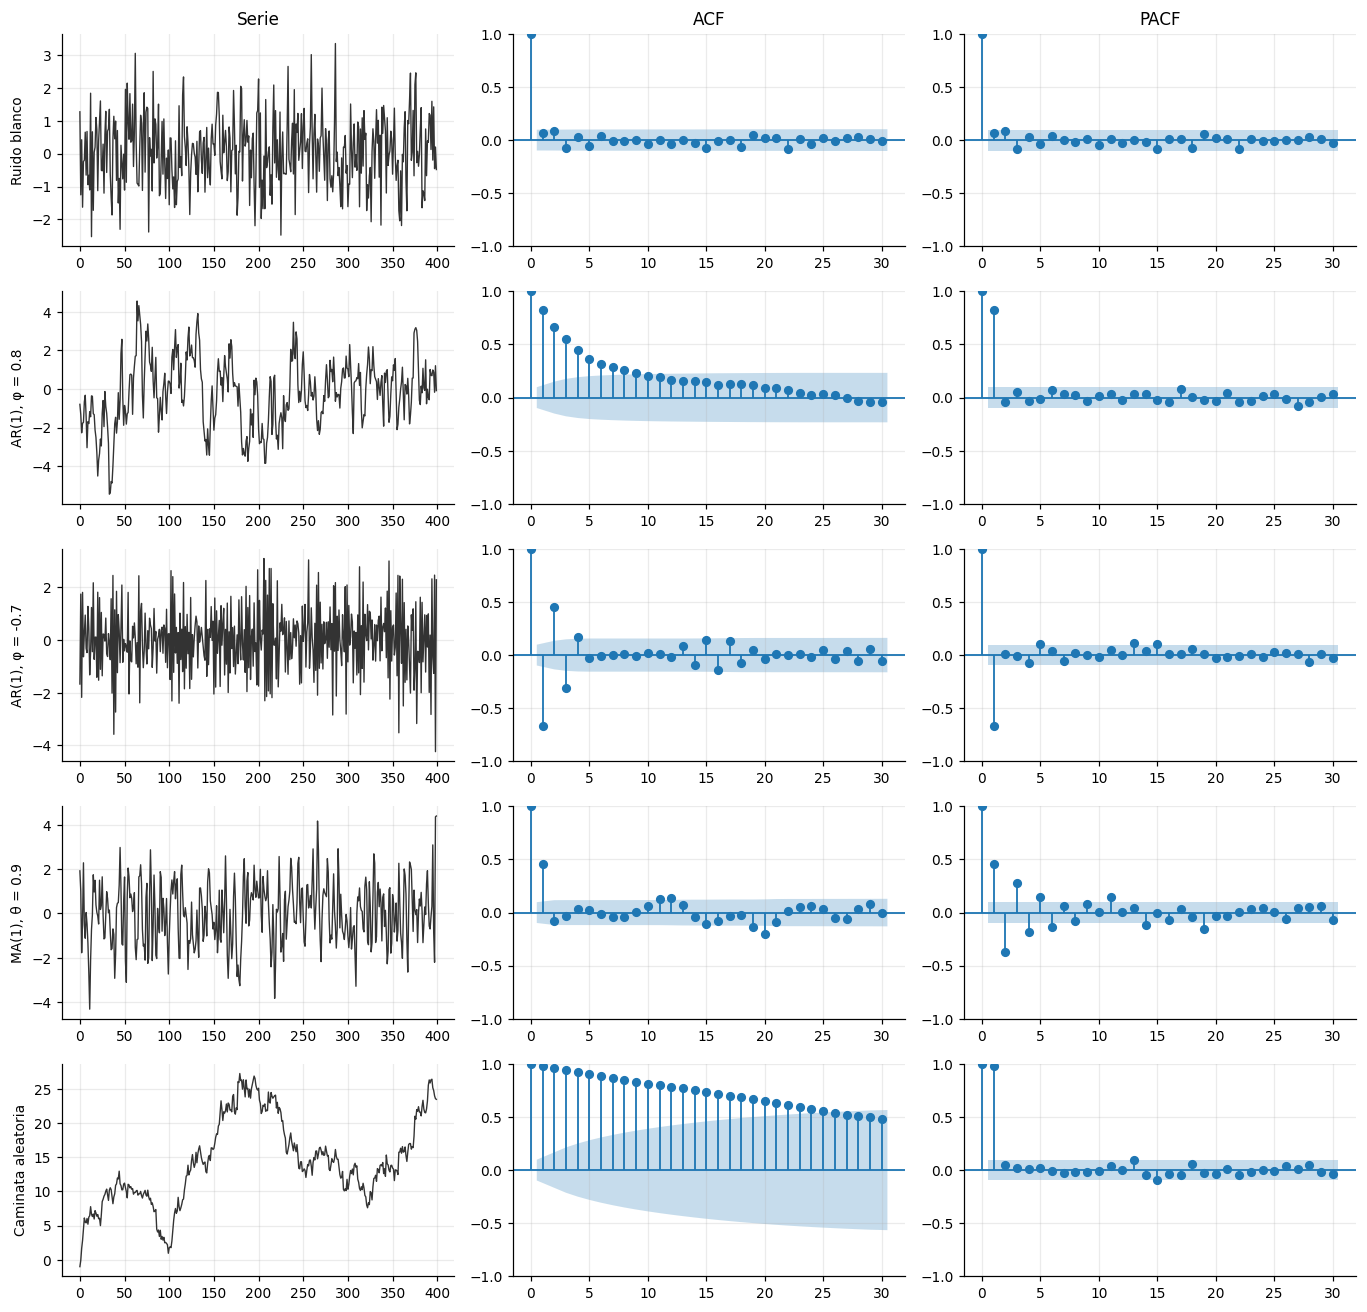

In [10]:
g = np.random.default_rng(SEMILLA)
n = 400
procesos = [
    (ruido_blanco(n, m=1, rng=g)[0],       "Ruido blanco"),
    (ar1(0.8, n, m=1, rng=g)[0],           "AR(1), φ = 0.8"),
    (ar1(-0.7, n, m=1, rng=g)[0],          "AR(1), φ = -0.7"),
    (ma1(0.9, n, m=1, rng=g)[0],           "MA(1), θ = 0.9"),
    (caminata_aleatoria(n, m=1, rng=g)[0], "Caminata aleatoria"),
]

fig, axes = plt.subplots(len(procesos), 3, figsize=(12.5, 12))
for fila, (serie, nombre) in enumerate(procesos):
    axes[fila, 0].plot(serie, lw=0.9, color="#333333")
    axes[fila, 0].set_ylabel(nombre, fontsize=9)
    if fila == 0:
        axes[fila, 0].set_title("Serie")
    plot_acf(serie, lags=30, ax=axes[fila, 1], title="ACF" if fila == 0 else "")
    plot_pacf(serie, lags=30, ax=axes[fila, 2], method="ywm",
              title="PACF" if fila == 0 else "")
plt.tight_layout(); plt.show()

### Guía de lectura de correlogramas

| Lo que observa | Interpretación | Acción sugerida |
|---|---|---|
| Todas las barras dentro de las bandas | Compatible con ruido blanco | No hay estructura lineal que modelar |
| ACF decae **exponencialmente**, PACF se corta en el rezago $p$ | Proceso **AR($p$)** | Sesión 3 |
| ACF se corta en el rezago $q$, PACF decae | Proceso **MA($q$)** | Sesión 3 |
| Ambas decaen gradualmente | Proceso **ARMA** mixto | Sesión 4 |
| ACF decae **muy lentamente y casi lineal** | Serie **no estacionaria** | Diferenciar antes de identificar |
| Picos en los rezagos 12, 24, 36 (datos mensuales) | Componente **estacional** | Diferenciación estacional / SARIMA |
| Alternancia de signo | Componente de alta frecuencia ($\phi<0$) | Revisar sobre-diferenciación |

> ### ⚠️ Advertencia metodológica
> La tabla anterior **presupone que la serie es estacionaria**. Aplicar ACF/PACF a una serie con tendencia produce un correlograma dominado por la tendencia, que no dice nada útil sobre la estructura de corto plazo. Veámoslo.

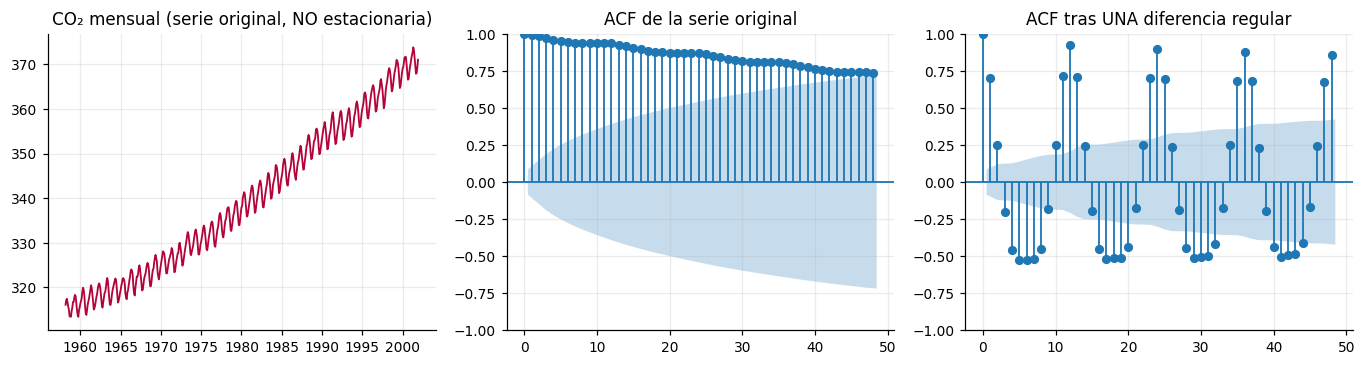

ACF de la serie original en los primeros rezagos:
[1.    0.993 0.982 0.971 0.961 0.952 0.945]

Decaimiento casi imperceptible => la ACF está midiendo la TENDENCIA, no la dinámica.
Tras diferenciar aparecen los picos en los rezagos 12, 24, 36: la ESTACIONALIDAD anual.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot(co2.index, co2.to_numpy(), color="#b30338")
axes[0].set_title("CO₂ mensual (serie original, NO estacionaria)")
plot_acf(co2.to_numpy(), lags=48, ax=axes[1], title="ACF de la serie original")
plot_acf(co2.diff().dropna().to_numpy(), lags=48, ax=axes[2],
         title="ACF tras UNA diferencia regular")
plt.tight_layout(); plt.show()

print("ACF de la serie original en los primeros rezagos:")
print(np.round(acf(co2.to_numpy(), nlags=6), 3))
print("\nDecaimiento casi imperceptible => la ACF está midiendo la TENDENCIA, no la dinámica.")
print("Tras diferenciar aparecen los picos en los rezagos 12, 24, 36: la ESTACIONALIDAD anual.")

---
# 6. Por qué la autocorrelación rompe la inferencia clásica

Todo el aparato de la regresión lineal clásica descansa sobre el supuesto de **errores independientes**. Al ajustar

$$x_t = \beta_0 + \beta_1 t + \varepsilon_t,$$

el error estándar de la pendiente que reporta MCO es

$$\operatorname{ee}(\hat{\beta}_1) = \sqrt{\frac{\hat{\sigma}^2}{\sum_t (t-\bar{t})^2}},$$

fórmula **válida únicamente si** $\operatorname{Cov}(\varepsilon_t, \varepsilon_s) = 0$ para $t \neq s$.

Cuando los errores están positivamente autocorrelacionados, cada observación aporta *menos información nueva* que una observación independiente: el **tamaño muestral efectivo** es menor que $n$. El error estándar reportado queda **subestimado**, el estadístico $t$ **inflado** y el valor-p **artificialmente pequeño**.

Veámoslo primero en un caso único y luego cuantifiquémoslo.

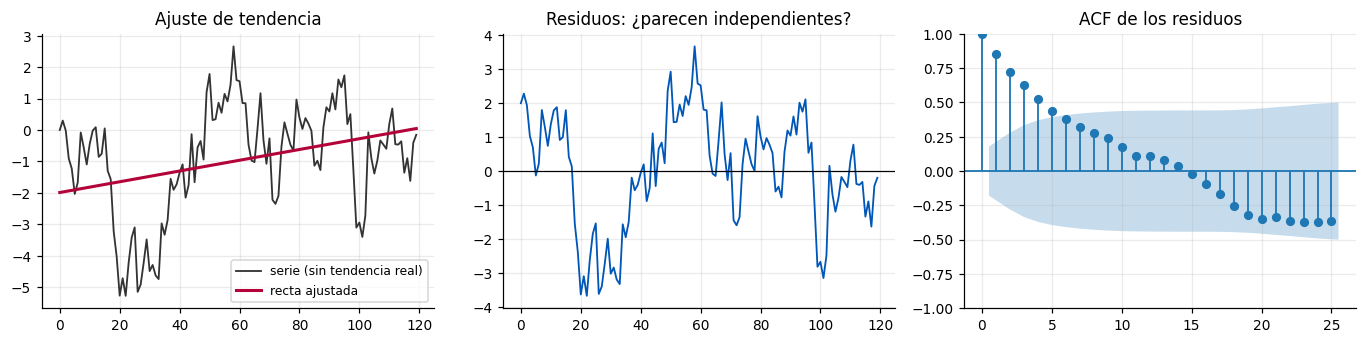

Pendiente estimada  :  0.01711   (VERDAD: 0.00000)
Error estándar (MCO):  0.00441
Estadístico t       :  3.883
Valor-p             :  0.0002  -> RECHAZA H0: declara tendencia significativa (FALSO POSITIVO)

Durbin-Watson       :  0.288   (≈2 sin autocorrelación; <1.5 alerta)
Ljung-Box (10 lags) p:  5.78e-62  -> los residuos NO son ruido blanco


In [13]:
# Un AR(1) SIN NINGUNA TENDENCIA: por construccion, beta_1 verdadero = 0.
n = 120
y = ar1(0.85, n, m=1, rng=np.random.default_rng(7))[0]
t = np.arange(n, dtype=float)
X = sm.add_constant(t)

modelo = sm.OLS(y, X).fit()
resid = modelo.resid

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
axes[0].plot(t, y, color="#333333", label="serie (sin tendencia real)")
axes[0].plot(t, modelo.fittedvalues, color="#b30338", lw=2, label="recta ajustada")
axes[0].set_title("Ajuste de tendencia"); axes[0].legend(fontsize=8)
axes[1].plot(t, resid, color="#0057b8"); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Residuos: ¿parecen independientes?")
from statsmodels.graphics.tsaplots import plot_acf as _pacf_plot
_pacf_plot(resid, lags=25, ax=axes[2], title="ACF de los residuos")
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(resid, lags=[10], return_df=True)
print(f"Pendiente estimada  : {modelo.params[1]: .5f}   (VERDAD: 0.00000)")
print(f"Error estándar (MCO): {modelo.bse[1]: .5f}")
print(f"Estadístico t       : {modelo.tvalues[1]: .3f}")
print(f"Valor-p             : {modelo.pvalues[1]: .4f}  -> "
      f"{'RECHAZA H0: declara tendencia significativa (FALSO POSITIVO)' if modelo.pvalues[1] < 0.05 else 'no rechaza'}")
print(f"\nDurbin-Watson       : {durbin_watson(resid): .3f}   (≈2 sin autocorrelación; <1.5 alerta)")
print(f"Ljung-Box (10 lags) p: {lb['lb_pvalue'].iloc[0]: .2e}  -> los residuos NO son ruido blanco")

Un caso aislado podría ser mala suerte. La pregunta correcta es **con qué frecuencia** ocurre este error. Eso se responde con una simulación de Monte Carlo: generamos miles de series **sin tendencia**, aplicamos el procedimiento de la Gerencia Comercial y contamos cuántas veces declara una tendencia significativa.

Si el procedimiento fuese válido, la tasa de falsos positivos debería ser exactamente el nivel de significancia, **5%**.

φ (autocorrelación),Falsos positivos MCO,Falsos positivos HAC
0.00,5.0%,7.9%
0.30,13.9%,9.6%
0.60,32.6%,15.1%
0.80,51.1%,27.7%
0.95,74.4%,55.1%
1.00 (caminata),88.6%,78.9%


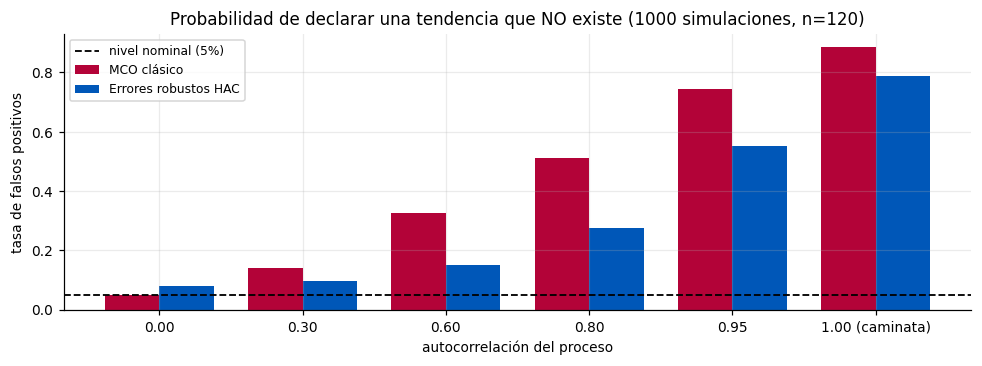

In [14]:
def tasa_falsos_positivos(phi, n=120, n_sim=1000, alpha=0.05, semilla=SEMILLA):
    '''Proporcion de veces que se declara tendencia significativa en series SIN tendencia.'''
    g = np.random.default_rng(semilla)
    Y = (caminata_aleatoria(n, m=n_sim, rng=g) if phi >= 1
         else ar1(phi, n, m=n_sim, rng=g))
    X = sm.add_constant(np.arange(n, dtype=float))
    maxlags = int(np.floor(4 * (n / 100) ** (2 / 9)))     # regla de Newey-West
    rech_mco = rech_hac = 0
    for i in range(n_sim):
        rech_mco += sm.OLS(Y[i], X).fit().pvalues[1] < alpha
        rech_hac += sm.OLS(Y[i], X).fit(
            cov_type="HAC", cov_kwds={"maxlags": maxlags}).pvalues[1] < alpha
    return rech_mco / n_sim, rech_hac / n_sim


phis = [0.0, 0.3, 0.6, 0.8, 0.95, 1.0]
filas = []
for phi in phis:
    mco, hac = tasa_falsos_positivos(phi)
    filas.append({"φ (autocorrelación)": "1.00 (caminata)" if phi >= 1 else f"{phi:.2f}",
                  "Falsos positivos MCO": mco,
                  "Falsos positivos HAC": hac})

tabla = pd.DataFrame(filas)
display(tabla.style.format({"Falsos positivos MCO": "{:.1%}",
                            "Falsos positivos HAC": "{:.1%}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(phis))
ax.bar(x - 0.19, tabla["Falsos positivos MCO"], 0.38, label="MCO clásico", color="#b30338")
ax.bar(x + 0.19, tabla["Falsos positivos HAC"], 0.38, label="Errores robustos HAC", color="#0057b8")
ax.axhline(0.05, color="k", ls="--", lw=1.2, label="nivel nominal (5%)")
ax.set_xticks(x); ax.set_xticklabels(tabla["φ (autocorrelación)"])
ax.set_xlabel("autocorrelación del proceso"); ax.set_ylabel("tasa de falsos positivos")
ax.set_title("Probabilidad de declarar una tendencia que NO existe (1000 simulaciones, n=120)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

🧭 **Pausa analítica — lea la tabla antes de continuar**

- Con $\varphi = 0$ (datos independientes) la tasa de falsos positivos es ≈5%: la teoría clásica funciona **cuando sus supuestos se cumplen**.
- Con $\varphi = 0{,}8$ la tasa supera el 50%: **la prueba se equivoca más de la mitad de las veces**.
- Con una caminata aleatoria la tasa se acerca al 90%. Este es el fenómeno de la **regresión espuria** (Granger y Newbold, 1974): correr MCO sobre series no estacionarias produce relaciones "significativas" entre variables que no tienen ninguna relación.

**Sobre los errores robustos HAC (Newey-West):** reducen el problema pero **no lo resuelven**. Son una corrección asintótica; con $n$ moderado siguen sobre-rechazando, y con series no estacionarias fallan por completo. La solución correcta no es parchar el error estándar, sino **modelar explícitamente la dependencia** (ARIMA) o **transformar la serie hasta hacerla estacionaria**. Eso es lo que haremos a continuación.

> ### 🎯 Regla de oro
> **Un valor-p calculado sobre residuos autocorrelacionados no significa nada.**  
> Revise *siempre* la ACF de los residuos antes de interpretar cualquier coeficiente.


---
# 7. Estacionariedad: la condición que hace todo posible

Una serie es **estacionaria en covarianza** (o débilmente estacionaria) si cumple simultáneamente:

1. $\mathbb{E}[X_t] = \mu$ **constante** — sin tendencia ni nivel cambiante.
2. $\operatorname{Var}(X_t) = \sigma^2 < \infty$ **constante** — sin heterocedasticidad.
3. $\operatorname{Cov}(X_t, X_{t+k}) = \gamma_k$ depende **solo del rezago $k$**, no del momento $t$.

La condición 3 es la que permite estimar: si $\gamma_k$ dependiera de $t$, cada par $(X_t, X_{t+k})$ sería una observación de un parámetro distinto y no habría nada que promediar.

### Cómo evaluarla: tres evidencias complementarias

| Evidencia | Qué mira | Limitación |
|---|---|---|
| **Visual** (media y desv. móviles) | Nivel y dispersión a lo largo del tiempo | Subjetiva |
| **ACF** | Velocidad de decaimiento | Cualitativa |
| **Pruebas formales** (ADF, KPSS) | Hipótesis contrastable | Baja potencia en muestras cortas |

Nunca decida con una sola. Y note que **ADF y KPSS plantean hipótesis nulas opuestas**, por lo que se usan en conjunto.

In [15]:
def grafico_estabilidad(serie, ventana=12, titulo=""):
    '''Media y desviacion movil: primer diagnostico visual de estacionariedad.'''
    s = pd.Series(np.asarray(serie, dtype=float))
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(s.to_numpy(), color="#cccccc", lw=0.9, label="serie")
    ax.plot(s.rolling(ventana).mean().to_numpy(), color="#b30338", lw=1.8,
            label=f"media móvil ({ventana})")
    ax.plot(s.rolling(ventana).std().to_numpy(), color="#0057b8", lw=1.8,
            label=f"desv. estándar móvil ({ventana})")
    ax.set_title(titulo or "Estabilidad de media y varianza"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def diagnostico_estacionariedad(serie, nombre="serie", alpha=0.05):
    '''Aplica ADF y KPSS y entrega una conclusion conjunta.'''
    x = np.asarray(serie, dtype=float)
    x = x[~np.isnan(x)]
    p_adf = adfuller(x, autolag="AIC")[1]
    p_kpss = kpss(x, regression="c", nlags="auto")[1]
    adf_est = p_adf < alpha        # ADF: H0 = raiz unitaria (NO estacionaria)
    kpss_est = p_kpss > alpha      # KPSS: H0 = estacionaria

    if adf_est and kpss_est:
        veredicto = "ESTACIONARIA (ambas pruebas concuerdan)"
    elif not adf_est and not kpss_est:
        veredicto = "NO ESTACIONARIA (ambas pruebas concuerdan) → diferenciar"
    elif adf_est and not kpss_est:
        veredicto = "AMBIGUO: posible estacionariedad en tendencia → quitar tendencia determinista"
    else:
        veredicto = "AMBIGUO: posible memoria larga → revisar (modelos ARFIMA, sesión posterior)"

    print(f"── {nombre} " + "─" * max(0, 60 - len(nombre)))
    print(f"   ADF  p = {p_adf:7.4f}  (H0: raíz unitaria)     → {'estacionaria' if adf_est else 'NO estacionaria'}")
    print(f"   KPSS p = {p_kpss:7.4f}  (H0: estacionaria)      → {'estacionaria' if kpss_est else 'NO estacionaria'}")
    print(f"   VEREDICTO: {veredicto}\n")
    return {"serie": nombre, "p_adf": p_adf, "p_kpss": p_kpss, "veredicto": veredicto}


g = np.random.default_rng(SEMILLA)
_ = diagnostico_estacionariedad(ruido_blanco(300, m=1, rng=g)[0], "Ruido blanco")
_ = diagnostico_estacionariedad(ar1(0.7, 300, m=1, rng=g)[0], "AR(1) φ=0.7")
_ = diagnostico_estacionariedad(caminata_aleatoria(300, m=1, rng=g)[0], "Caminata aleatoria")
_ = diagnostico_estacionariedad(co2.to_numpy(), "CO₂ (serie original)")

── Ruido blanco ────────────────────────────────────────────────
   ADF  p =  0.0000  (H0: raíz unitaria)     → estacionaria
   KPSS p =  0.1000  (H0: estacionaria)      → estacionaria
   VEREDICTO: ESTACIONARIA (ambas pruebas concuerdan)

── AR(1) φ=0.7 ─────────────────────────────────────────────────
   ADF  p =  0.0000  (H0: raíz unitaria)     → estacionaria
   KPSS p =  0.1000  (H0: estacionaria)      → estacionaria
   VEREDICTO: ESTACIONARIA (ambas pruebas concuerdan)

── Caminata aleatoria ──────────────────────────────────────────
   ADF  p =  0.0765  (H0: raíz unitaria)     → NO estacionaria
   KPSS p =  0.0100  (H0: estacionaria)      → NO estacionaria
   VEREDICTO: NO ESTACIONARIA (ambas pruebas concuerdan) → diferenciar

── CO₂ (serie original) ────────────────────────────────────────
   ADF  p =  0.9989  (H0: raíz unitaria)     → NO estacionaria
   KPSS p =  0.0100  (H0: estacionaria)      → NO estacionaria
   VEREDICTO: NO ESTACIONARIA (ambas pruebas concuerdan) → diferen

### Matriz de decisión ADF × KPSS

| | **KPSS no rechaza** (parece estacionaria) | **KPSS rechaza** (parece no estacionaria) |
|---|---|---|
| **ADF rechaza** (parece estacionaria) | ✅ Estacionaria. Modele directamente. | ⚠️ Estacionaria en tendencia: elimine una tendencia determinista. |
| **ADF no rechaza** (parece no estacionaria) | ⚠️ Poca información / memoria larga: revise, considere ARFIMA. | 🔁 No estacionaria: **diferencie** y vuelva a evaluar. |

### El orden de las transformaciones importa

1. **Estabilizar la varianza primero** (logaritmo o Box-Cox), si la dispersión crece con el nivel.
2. **Diferenciación estacional** ($\nabla_{12}$), si hay estacionalidad marcada.
3. **Diferenciación regular** ($\nabla$), si aún persiste tendencia o nivel cambiante.

> ⚠️ **No sobre-diferencie.** Cada diferencia adicional destruye información e introduce autocorrelación negativa artificial (una ACF con un pico negativo grande en el rezago 1 es la señal típica). En la práctica, $d \le 2$ casi siempre basta.

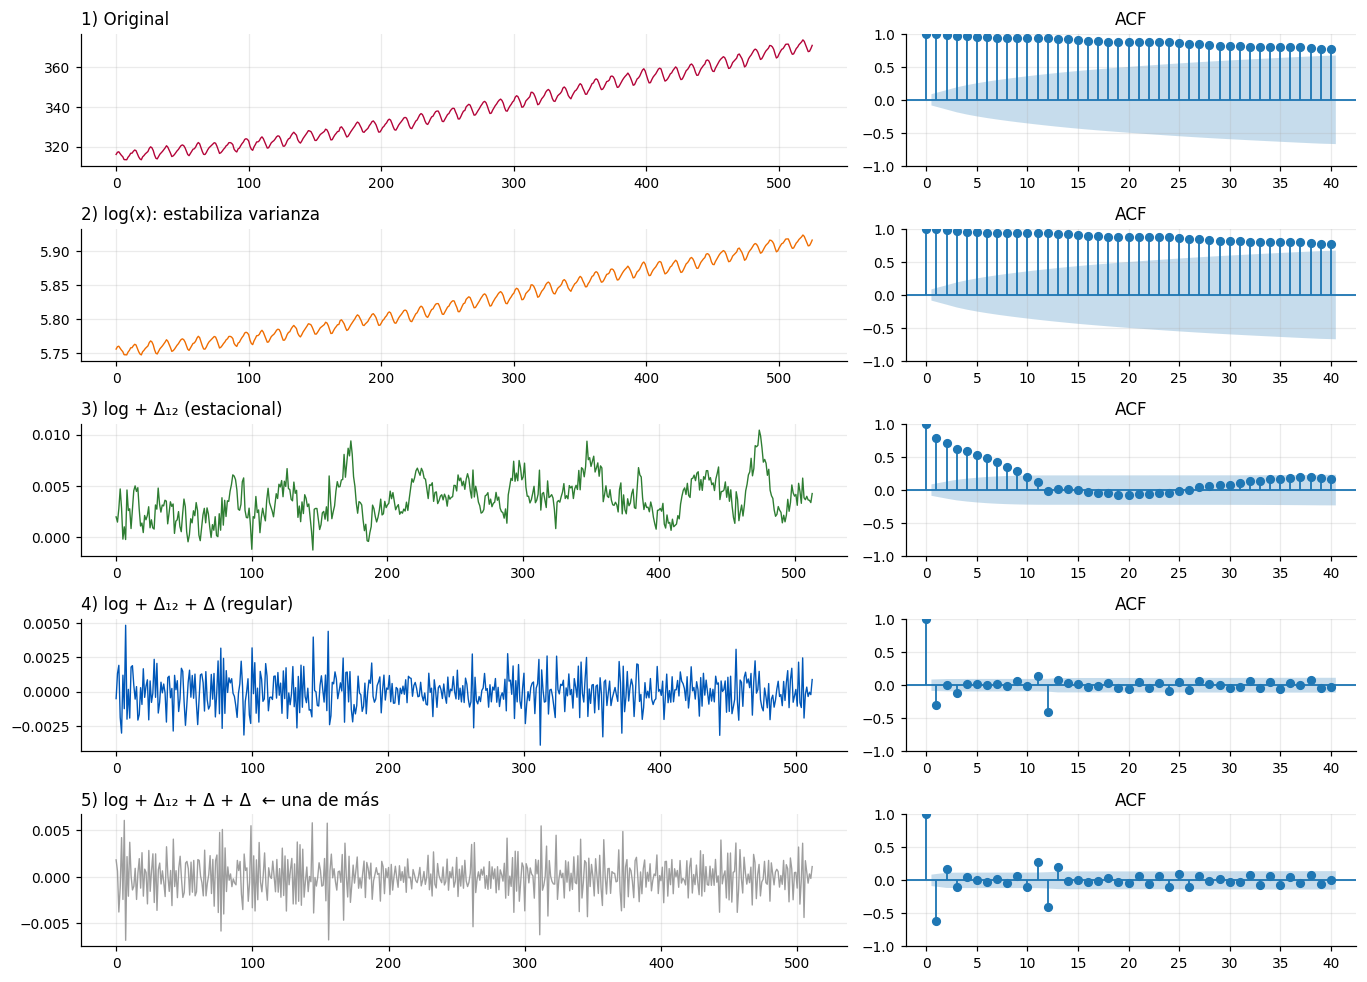

── 1) Original ─────────────────────────────────────────────────
   ADF  p =  0.9989  (H0: raíz unitaria)     → NO estacionaria
   KPSS p =  0.0100  (H0: estacionaria)      → NO estacionaria
   VEREDICTO: NO ESTACIONARIA (ambas pruebas concuerdan) → diferenciar

── 2) log(x): estabiliza varianza ──────────────────────────────
   ADF  p =  0.9985  (H0: raíz unitaria)     → NO estacionaria
   KPSS p =  0.0100  (H0: estacionaria)      → NO estacionaria
   VEREDICTO: NO ESTACIONARIA (ambas pruebas concuerdan) → diferenciar

── 3) log + Δ₁₂ (estacional) ───────────────────────────────────
   ADF  p =  0.0001  (H0: raíz unitaria)     → estacionaria
   KPSS p =  0.0100  (H0: estacionaria)      → NO estacionaria
   VEREDICTO: AMBIGUO: posible estacionariedad en tendencia → quitar tendencia determinista

── 4) log + Δ₁₂ + Δ (regular) ──────────────────────────────────
   ADF  p =  0.0000  (H0: raíz unitaria)     → estacionaria
   KPSS p =  0.1000  (H0: estacionaria)      → estacionaria
   VERED

In [16]:
def diferencia_estacional(x, s=12):
    '''Diferencia ESTACIONAL: x_t - x_{t-s}.

    Cuidado: np.diff(x, n=12) NO hace esto. Aplica la primera diferencia
    doce veces seguidas, que es una operacion completamente distinta.
    '''
    x = np.asarray(x, dtype=float)
    return x[s:] - x[:-s]


log_co2 = np.log(co2.to_numpy())
transformaciones = [
    (co2.to_numpy(),                                   "1) Original", "#b30338"),
    (log_co2,                                          "2) log(x): estabiliza varianza", "#ef6c00"),
    (diferencia_estacional(log_co2, 12),               "3) log + Δ₁₂ (estacional)", "#2e7d32"),
    (np.diff(diferencia_estacional(log_co2, 12)),      "4) log + Δ₁₂ + Δ (regular)", "#0057b8"),
    (np.diff(np.diff(diferencia_estacional(log_co2, 12))), "5) log + Δ₁₂ + Δ + Δ  ← una de más", "#9e9e9e"),
]

fig, axes = plt.subplots(len(transformaciones), 2, figsize=(12.5, 9),
                         gridspec_kw={"width_ratios": [1.7, 1]})
for fila, (serie, titulo, color) in enumerate(transformaciones):
    axes[fila, 0].plot(serie, color=color, lw=0.9)
    axes[fila, 0].set_title(titulo, loc="left")
    plot_acf(serie, lags=40, ax=axes[fila, 1], title="ACF")
plt.tight_layout(); plt.show()

resumen = [diagnostico_estacionariedad(s, t) for s, t, _ in transformaciones]

print(f"{'Transformación':<40}{'ρ₁':>8}{'varianza':>14}")
for serie, titulo, _ in transformaciones:
    print(f"   {titulo:<37}{acf(serie, nlags=1)[1]:>+8.3f}{np.var(serie):>14.3e}")
print('''
CÓMO LEER ESTA TABLA
  Paso 3 → elimina la estacionalidad, pero KPSS sigue rechazando: queda la
           deriva creciente. La transformación es necesaria pero insuficiente.
  Paso 4 → ambas pruebas concuerdan en estacionariedad y la VARIANZA CAE.
           El ρ₁ = -0.30 no es alarma: es la firma MA(1) característica de una
           serie correctamente diferenciada (el 'modelo aerolínea' clásico).
  Paso 5 → una diferencia de más. ρ₁ se vuelve fuertemente negativo Y la
           VARIANZA AUMENTA respecto del paso 4. Ese aumento de varianza es el
           criterio práctico más confiable para detectar sobre-diferenciación.

Nota: las varianzas solo son comparables entre series en la MISMA escala,
es decir entre los pasos 3, 4 y 5 (todos en logaritmos). Comparar el paso 1
con el 2 no tiene sentido: el logaritmo cambia las unidades.

REGLA: diferencie mientras la varianza baje; deténgase cuando empiece a subir.
''')

🧭 **Pausa analítica**

1. En el paso 3 desaparecen los picos de los rezagos 12, 24 y 36. ¿Qué componente fue removido? Sin embargo, KPSS sigue rechazando. ¿Qué quedó sin remover?
2. Entre los pasos 4 y 5, ¿por qué el aumento de la varianza es una señal de alarma más confiable que el simple hecho de que $\rho_1$ sea negativo?
3. ¿Por qué el logaritmo se aplica *antes* de las diferencias y no después?
4. La serie resultante del paso 4 tiene la estructura del llamado "modelo aerolínea", ARIMA(0,1,1)(0,1,1)$_{12}$. Anticipe: ¿qué esperaría ver en la ACF de sus residuos si el modelo fuese adecuado?

*Escriba su respuesta aquí:*

---

---
# 8. Flujo de trabajo del analista de series de tiempo

Este protocolo se aplicará, con extensiones, durante toda la asignatura.

```
   ┌─────────────────────────────────────────────────────────────┐
   │ 1. GRAFICAR         serie completa + subperiodos            │
   │                     ¿tendencia? ¿estacionalidad? ¿quiebres? │
   ├─────────────────────────────────────────────────────────────┤
   │ 2. LIMPIAR          faltantes, atípicos, frecuencia regular │
   ├─────────────────────────────────────────────────────────────┤
   │ 3. ESTABILIZAR      log / Box-Cox si la varianza crece      │
   ├─────────────────────────────────────────────────────────────┤
   │ 4. ESTACIONARIZAR   diferenciar; verificar con ADF + KPSS   │
   ├─────────────────────────────────────────────────────────────┤
   │ 5. IDENTIFICAR      leer ACF y PACF → órdenes candidatos    │  ← sesiones 3-4
   ├─────────────────────────────────────────────────────────────┤
   │ 6. ESTIMAR          ajustar modelo, comparar por AIC/BIC    │  ← sesiones 3-4
   ├─────────────────────────────────────────────────────────────┤
   │ 7. VALIDAR          ACF de residuos + Ljung-Box             │  ← criterio de cierre
   │                     ¿residuos ≈ ruido blanco?  NO → paso 5  │
   ├─────────────────────────────────────────────────────────────┤
   │ 8. PRONOSTICAR      con intervalos; evaluar fuera de muestra│  ← sesiones 5+
   └─────────────────────────────────────────────────────────────┘
```

Así dominamos los pasos 1 a 4 y el criterio del paso 7.

---
# 9. Resolución del problema

Volvamos al correo de la Gerencia Comercial. Aquí están las dos series de demanda semanal.

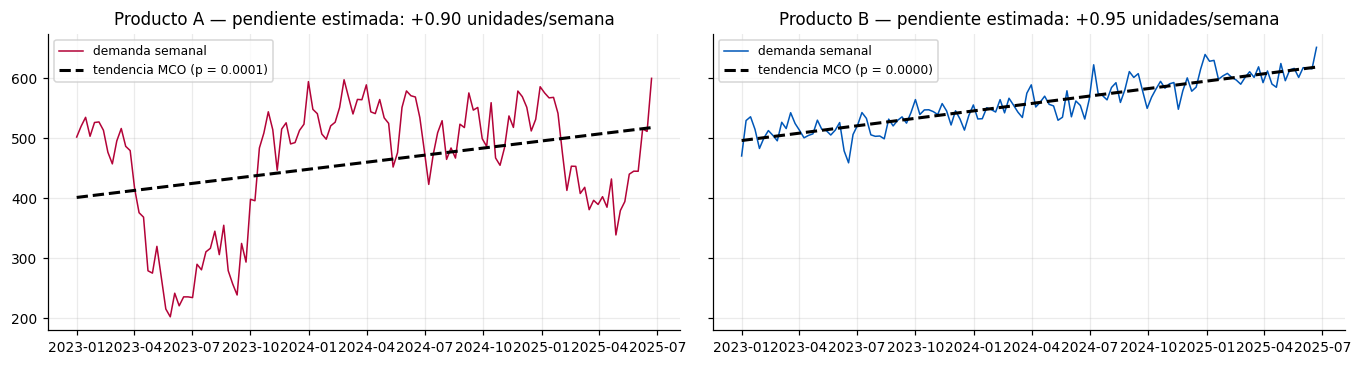

Ambas pendientes son 'significativas' según MCO. La Gerencia tiene razón... ¿o no?


In [17]:
# ---------------------------------------------------------------------------
# Series del caso. El proceso generador se revela mas abajo: NO mire todavia.
# ---------------------------------------------------------------------------
def series_del_caso(semilla=2015, n=130):
    g = np.random.default_rng(semilla)
    idx = pd.date_range("2023-01-01", periods=n, freq="W")
    a = 500 + 40 * ar1(0.93, n, m=1, rng=g)[0]                       # producto A
    b = 500 + 0.9 * np.arange(n) + 18 * ar1(0.35, n, m=1, rng=g)[0]  # producto B
    return (pd.Series(a, index=idx, name="Producto A"),
            pd.Series(b, index=idx, name="Producto B"))


prod_a, prod_b = series_del_caso()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4), sharey=True)
for ax, s, color in [(axes[0], prod_a, "#b30338"), (axes[1], prod_b, "#0057b8")]:
    t = np.arange(len(s), dtype=float)
    ajuste = sm.OLS(s.to_numpy(), sm.add_constant(t)).fit()
    ax.plot(s.index, s.to_numpy(), color=color, lw=1.0, label="demanda semanal")
    ax.plot(s.index, ajuste.fittedvalues, color="k", lw=2, ls="--",
            label=f"tendencia MCO (p = {ajuste.pvalues[1]:.4f})")
    ax.set_title(f"{s.name} — pendiente estimada: {ajuste.params[1]:+.2f} unidades/semana")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Ambas pendientes son 'significativas' según MCO. La Gerencia tiene razón... ¿o no?")


PRODUCTO A
(1) MCO clásico — el procedimiento de la Gerencia
    pendiente +0.903   ee=0.229   p=0.0001   → SIGNIFICATIVA
(2) MCO con errores robustos HAC — corrección parcial
    pendiente +0.903   ee=0.508   p=0.0758   → no significativa
    el error estándar robusto es 2.2× el de MCO
(3) AR(1) con tendencia — el modelo que SÍ reconoce la dependencia
    pendiente +0.851   ee=0.883   p=0.3350   → no significativa
    φ estimado = 0.912

Diagnóstico de los residuos de (1):
    Durbin-Watson: 0.173   (≈2 si no hay autocorrelación)
    Ljung-Box(10): p=1.08e-109 → AUTOCORRELACIONADOS: la inferencia de (1) NO es válida

PRODUCTO B
(1) MCO clásico — el procedimiento de la Gerencia
    pendiente +0.949   ee=0.043   p=0.0000   → SIGNIFICATIVA
(2) MCO con errores robustos HAC — corrección parcial
    pendiente +0.949   ee=0.051   p=0.0000   → SIGNIFICATIVA
    el error estándar robusto es 1.2× el de MCO
(3) AR(1) con tendencia — el modelo que SÍ reconoce la dependencia
    pendiente +0.959 

,MCO clásico,MCO + HAC,AR(1) con tendencia
PRODUCTO A,0.0001,0.0758,0.3350
PRODUCTO B,0.0000,0.0000,0.0000


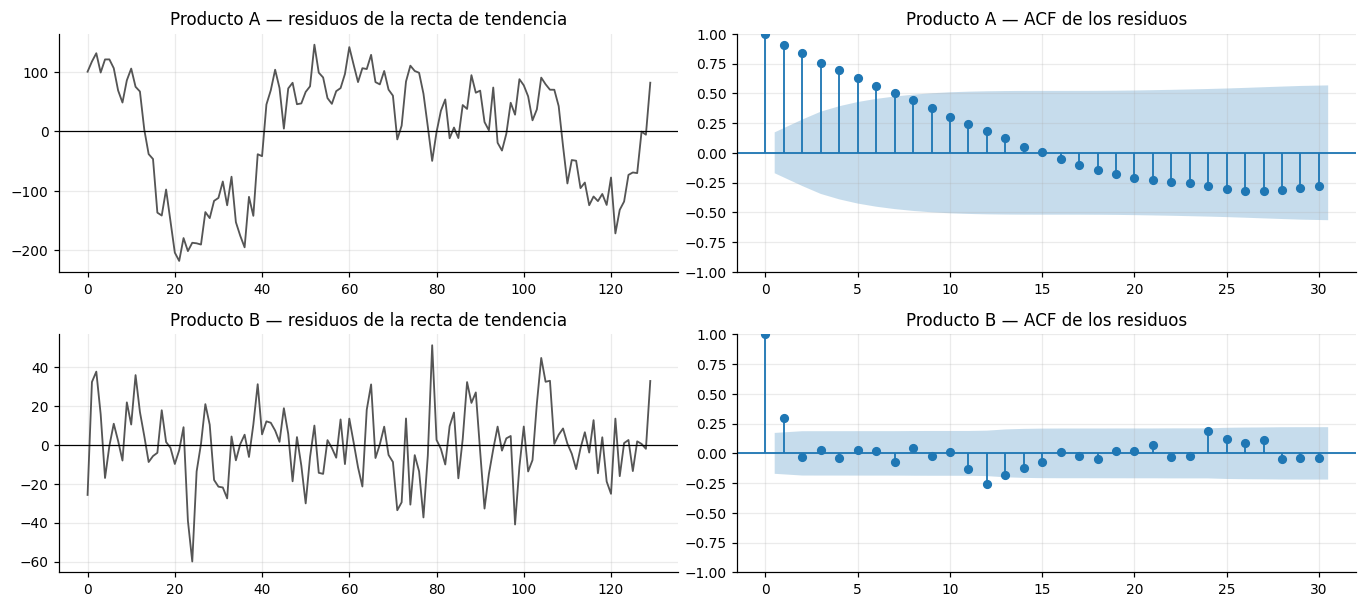

In [18]:
# --- Diagnostico completo: exactamente el protocolo de la seccion 8 ---
def auditar_tendencia(serie, nombre):
    y = serie.to_numpy(dtype=float)
    n = len(y)
    t = np.arange(n, dtype=float)
    X = sm.add_constant(t)
    maxlags = int(np.floor(4 * (n / 100) ** (2 / 9)))

    mco = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    # (3) Modelo que SI reconoce la dependencia: AR(1) con tendencia lineal.
    #     Anticipo de los modelos ARIMA de las sesiones 3-4.
    arima = ARIMA(y, order=(1, 0, 0), trend="ct").fit()
    resid = mco.resid
    lb_p = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

    def marca(p):
        return "SIGNIFICATIVA" if p < 0.05 else "no significativa"

    print(f"\n{'='*72}\n{nombre}\n{'='*72}")
    print("(1) MCO clásico — el procedimiento de la Gerencia")
    print(f"    pendiente {mco.params[1]:+.3f}   ee={mco.bse[1]:.3f}   p={mco.pvalues[1]:.4f}   → {marca(mco.pvalues[1])}")
    print("(2) MCO con errores robustos HAC — corrección parcial")
    print(f"    pendiente {hac.params[1]:+.3f}   ee={hac.bse[1]:.3f}   p={hac.pvalues[1]:.4f}   → {marca(hac.pvalues[1])}")
    print(f"    el error estándar robusto es {hac.bse[1]/mco.bse[1]:.1f}× el de MCO")
    print("(3) AR(1) con tendencia — el modelo que SÍ reconoce la dependencia")
    print(f"    pendiente {arima.params[1]:+.3f}   ee={arima.bse[1]:.3f}   p={arima.pvalues[1]:.4f}   → {marca(arima.pvalues[1])}")
    print(f"    φ estimado = {arima.params[2]:.3f}")
    print("\nDiagnóstico de los residuos de (1):")
    print(f"    Durbin-Watson: {durbin_watson(resid):.3f}   (≈2 si no hay autocorrelación)")
    print(f"    Ljung-Box(10): p={lb_p:.2e} → "
          f"{'AUTOCORRELACIONADOS: la inferencia de (1) NO es válida' if lb_p < 0.05 else 'compatibles con ruido blanco'}")
    return {"nombre": nombre, "p_mco": mco.pvalues[1],
            "p_hac": hac.pvalues[1], "p_arima": arima.pvalues[1], "lb_p": lb_p}


audit = pd.DataFrame([auditar_tendencia(prod_a, "PRODUCTO A"),
                      auditar_tendencia(prod_b, "PRODUCTO B")])
print("\n\nRESUMEN COMPARATIVO (valores-p de la pendiente)")
display(audit[["nombre", "p_mco", "p_hac", "p_arima"]]
        .rename(columns={"nombre": "", "p_mco": "MCO clásico",
                         "p_hac": "MCO + HAC", "p_arima": "AR(1) con tendencia"})
        .style.format({"MCO clásico": "{:.4f}", "MCO + HAC": "{:.4f}",
                       "AR(1) con tendencia": "{:.4f}"}).hide(axis="index"))

fig, axes = plt.subplots(2, 2, figsize=(12.5, 5.6))
for fila, s in enumerate([prod_a, prod_b]):
    y = s.to_numpy(dtype=float)
    r = sm.OLS(y, sm.add_constant(np.arange(len(y), dtype=float))).fit().resid
    axes[fila, 0].plot(r, color="#555555"); axes[fila, 0].axhline(0, color="k", lw=0.8)
    axes[fila, 0].set_title(f"{s.name} — residuos de la recta de tendencia")
    plot_acf(r, lags=30, ax=axes[fila, 1], title=f"{s.name} — ACF de los residuos")
plt.tight_layout(); plt.show()

### 🔎 Veredicto

Ejecute la celda siguiente **solo después** de haber escrito su propia conclusión.

*Mi conclusión antes de ver la respuesta:*

---

In [19]:
print(r'''
PROCESO GENERADOR REAL
──────────────────────────────────────────────────────────────────────────
Producto A:  500 + 40 · AR(1) con φ = 0.93          →  pendiente real = 0.00
             No hay ninguna tendencia. Toda la "subida" es el vagar de un
             proceso muy persistente. Es exactamente el escenario del
             experimento Monte Carlo de la §6: con φ = 0.93 y n = 130,
             cerca del 70% de las series SIN tendencia producen un
             valor-p de MCO menor a 0.05.

Producto B:  500 + 0.9·t + 18 · AR(1) con φ = 0.35  →  pendiente real = +0.90
             El crecimiento existe y es de aproximadamente 0.9 unidades
             por semana.

LO QUE HACE DIFÍCIL EL CASO
──────────────────────────────────────────────────────────────────────────
Las pendientes ESTIMADAS de A y B son prácticamente idénticas (≈ +0.9) y
ambas son "significativas" bajo MCO. Mirando solo el gráfico y el valor-p
es imposible distinguirlas. La diferencia aparece únicamente al examinar
la ESTRUCTURA DE DEPENDENCIA de los residuos:

    Producto A → Durbin-Watson ≈ 0.2, Ljung-Box rechaza con fuerza.
                 El error estándar de MCO está gravemente subestimado.
                 Con errores robustos la significancia ya no se sostiene
                 al 5%, y con un modelo AR(1) con tendencia el valor-p
                 supera holgadamente 0.30: NO hay evidencia de tendencia.

    Producto B → Durbin-Watson algo bajo, pero Ljung-Box NO rechaza: la
                 dependencia residual es leve. Aun corrigiendo por ella, la
                 pendiente sigue siendo abrumadoramente significativa por
                 los tres procedimientos. La tendencia es real.

RESPUESTA AL CASO
──────────────────────────────────────────────────────────────────────────
La evidencia respalda el aumento de inventario SOLO para el Producto B.

  · Producto B → aumentar. Cuantificar el crecimiento con un modelo que
    incorpore la dependencia (ARIMA con término de tendencia) y proyectar
    la demanda del trimestre con intervalos de predicción.

  · Producto A → NO aumentar. Modelar la serie como un proceso estacionario
    en torno a un nivel medio y dimensionar el inventario según su
    VARIABILIDAD —que es alta— y no según una tendencia inexistente.

  · Informar a la Gerencia que el procedimiento empleado (MCO + valor-p
    sobre series autocorrelacionadas) no es válido, y proponer el protocolo
    de la §8 como estándar para futuras decisiones de inventario.
''')


PROCESO GENERADOR REAL
──────────────────────────────────────────────────────────────────────────
Producto A:  500 + 40 · AR(1) con φ = 0.93          →  pendiente real = 0.00
             No hay ninguna tendencia. Toda la "subida" es el vagar de un
             proceso muy persistente. Es exactamente el escenario del
             experimento Monte Carlo de la §6: con φ = 0.93 y n = 130,
             cerca del 70% de las series SIN tendencia producen un
             valor-p de MCO menor a 0.05.

Producto B:  500 + 0.9·t + 18 · AR(1) con φ = 0.35  →  pendiente real = +0.90
             El crecimiento existe y es de aproximadamente 0.9 unidades
             por semana.

LO QUE HACE DIFÍCIL EL CASO
──────────────────────────────────────────────────────────────────────────
Las pendientes ESTIMADAS de A y B son prácticamente idénticas (≈ +0.9) y
ambas son "significativas" bajo MCO. Mirando solo el gráfico y el valor-p
es imposible distinguirlas. La diferencia aparece únicamente al examinar


> ### 🎓 Lo que acaba de ocurrir
> Usted no aprendió una técnica: aprendió a **auditar una decisión de negocio** que parecía respaldada por estadística. Ese es el valor profesional de esta asignatura. Los modelos ARIMA, SARIMA y GARCH que veremos existen precisamente para hacer bien lo que MCO hace mal aquí.

---
# 10. Laboratorio — actividad evaluada

**Modalidad:** individual · **Entrega:** este notebook ejecutado (`.ipynb`) + exportación a HTML o PDF  
**Nombre del archivo:** `MCDI505_S1_ApellidoNombre.ipynb`  
**Carácter:** formativo con retroalimentación docente dentro de 5 días hábiles

**Instrucciones generales**

- Complete las celdas marcadas con `# TODO`. El código debe ejecutarse de principio a fin sin errores en un kernel reiniciado (*Kernel → Restart & Run All*).
- Cada ejercicio exige una **interpretación escrita**. Código sin interpretación no se considera una respuesta completa.
- Argumente toda afirmación con la evidencia que la respalda (gráfico, estadístico o valor-p). No basta con afirmar "la serie es estacionaria".

---

### Lista de cotejo (criterios de evaluación)

| # | Criterio | Logrado | No logrado |
|---|---|:--:|:--:|
| 1 | Grafica correctamente la serie e identifica sus componentes usando terminología precisa (tendencia / estacionalidad / ciclo / quiebre). | ☐ | ☐ |
| 2 | Calcula e interpreta ACF y PACF distinguiendo picos significativos del azar muestral. | ☐ | ☐ |
| 3 | Implementa la función solicitada y aprueba las pruebas automáticas incluidas. | ☐ | ☐ |
| 4 | Aplica ADF y KPSS e interpreta correctamente su resultado conjunto. | ☐ | ☐ |
| 5 | Selecciona y justifica una secuencia de transformaciones, verificando el resultado. | ☐ | ☐ |
| 6 | Explica con sus palabras por qué la autocorrelación invalida la inferencia clásica. | ☐ | ☐ |
| 7 | Redacta conclusiones vinculadas a una decisión, no solo a un estadístico. | ☐ | ☐ |
| 8 | El notebook se ejecuta completo sin errores y está ordenado y comentado. | ☐ | ☐ |

In [20]:
# =============================================================================
# EJERCICIO 1 — Caracterización visual  (criterios 1 y 7)
# Serie: manchas solares anuales (variable `sunspots`, ya cargada).
# =============================================================================

# TODO 1.1 — Grafique la serie completa y un subperiodo de 60 años.


# TODO 1.2 — ¿El patrón observado es ESTACIONALIDAD o CICLO? Estime su periodo
#            aproximado a partir del gráfico o de la ACF.


# TODO 1.3 — ¿La varianza parece constante en el tiempo? Use grafico_estabilidad().


# --- Respuesta escrita (mínimo 5 líneas) ---
# Componentes identificados:
# Periodo aproximado:
# Estacionalidad o ciclo, y por qué:
# Implicancia para el modelamiento:

In [21]:
# =============================================================================
# EJERCICIO 2 — Detector de ruido blanco  (criterios 2, 3 y 6)
# =============================================================================

def es_ruido_blanco(x, alpha=0.05, lags=10):
    '''Decide si una serie es compatible con ruido blanco.

    Debe devolver un dict con las claves:
        'p_valor'      : p-valor de la prueba de Ljung-Box en el rezago `lags`
        'es_rb'        : bool, True si NO se rechaza la hipotesis de ruido blanco
        'n_fuera_banda': numero de rezagos 1..`lags` cuya ACF cae fuera de
                         las bandas +-1.96/sqrt(n)
    '''
    # TODO 2.1 — implemente la función usando acorr_ljungbox y acf
    raise NotImplementedError


# --- Pruebas automáticas: su función debe aprobarlas todas ---
g_test = np.random.default_rng(123)
casos = [
    (ruido_blanco(500, m=1, rng=g_test)[0], True,  "ruido blanco puro"),
    (ar1(0.6, 500, m=1, rng=g_test)[0],     False, "AR(1) φ=0.6"),
    (ma1(0.8, 500, m=1, rng=g_test)[0],     False, "MA(1) θ=0.8"),
    (caminata_aleatoria(500, m=1, rng=g_test)[0], False, "caminata aleatoria"),
]
try:
    for serie, esperado, nombre in casos:
        r = es_ruido_blanco(serie)
        assert r["es_rb"] == esperado, f"Falla en: {nombre}"
        print(f"✔ {nombre:<22} p={r['p_valor']:.4f}  fuera de banda={r['n_fuera_banda']}")
    print("\nTodas las pruebas aprobadas ✔")
except NotImplementedError:
    print("⏳ Pendiente: implemente es_ruido_blanco() y vuelva a ejecutar esta celda.")

# TODO 2.2 — Explique en 3-4 líneas por qué es útil disponer de este detector
#            en el paso 7 del flujo de trabajo de la §8.

⏳ Pendiente: implemente es_ruido_blanco() y vuelva a ejecutar esta celda.


In [22]:
# =============================================================================
# EJERCICIO 3 — Estacionarización con justificación  (criterios 4, 5 y 7)
# Serie: caudal del Nilo (variable `nile`, ya cargada). Contiene un quiebre
# estructural documentado alrededor de 1899 (construcción de la presa de Asuán).
# =============================================================================

# TODO 3.1 — Diagnostique la serie original: gráfico, media/desv. móviles, ACF,
#            ADF y KPSS. ¿Concuerdan las pruebas?


# TODO 3.2 — Proponga y aplique UNA transformación. Vuelva a diagnosticar.


# TODO 3.3 — Un quiebre estructural puede hacer que ADF NO rechace la hipótesis
#            de raíz unitaria aunque la serie sea estacionaria por tramos.
#            Verifíquelo: aplique diagnostico_estacionariedad() por separado a
#            los datos anteriores y posteriores a 1899.


# --- Respuesta escrita ---
# Diagnóstico de la serie original:
# Transformación elegida y por qué:
# ¿Diferenciar es la respuesta correcta ante un quiebre estructural? Justifique:

In [23]:
# =============================================================================
# EJERCICIO 4 (DESAFÍO, opcional) — Regresión espuria  (criterios 6 y 7)
# =============================================================================
# Granger y Newbold (1974) mostraron que al regresionar una caminata aleatoria
# contra OTRA caminata aleatoria INDEPENDIENTE, la pendiente resulta
# significativa en una altísima proporción de los casos.
#
# TODO 4.1 — Simule 1000 pares de caminatas aleatorias independientes de
#            longitud 200. Para cada par ajuste  y = b0 + b1*x + e  y registre
#            el p-valor de b1 y el R cuadrado.
# TODO 4.2 — Reporte la proporción de p-valores < 0.05 y el R² mediano.
# TODO 4.3 — Repita usando las PRIMERAS DIFERENCIAS de ambas series.
#            ¿Qué ocurre con la tasa de rechazo? Explique por qué.

---
# 11. Errores frecuentes (y cómo evitarlos)

| Error | Por qué ocurre | Qué hacer |
|---|---|---|
| Interpretar ACF/PACF de una serie no estacionaria | Se aplica la receta sin verificar el supuesto | Estacionarizar primero; siempre |
| Afirmar "hay tendencia" por inspección visual | Las caminatas aleatorias *parecen* tener tendencia | Contrastar con pruebas formales y ACF de residuos |
| Confundir ciclo con estacionalidad | Ambos "se repiten" | ¿Periodo fijo de calendario? → estacionalidad |
| Sobre-diferenciar | "Por si acaso" | ACF con pico negativo grande en el rezago 1 = señal de alerta |
| Usar `train_test_split` aleatorio | Hábito heredado de aprendizaje supervisado | La partición debe ser **cronológica**; nunca mezclar el futuro con el pasado |
| Interpolar faltantes y no declararlo | Comodidad | La interpolación **crea** autocorrelación artificial; documéntela |
| Estandarizar usando media y desviación de toda la serie | Rutina de preprocesamiento | Provoca fuga de información (*leakage*) desde el conjunto de prueba |
| Confiar en $R^2$ para comparar modelos de series de tiempo | Analogía con regresión | Un $R^2$ alto es habitual y espurio; use error de pronóstico fuera de muestra |
| Reportar valores-p sin revisar los residuos | Salida automática de la librería | Ljung-Box + ACF de residuos, siempre |

---
# 12. Glosario español–inglés

Trabajará con bibliografía y documentación en inglés; conviene fijar la correspondencia desde el inicio.

| Español | Inglés | Símbolo / función |
|---|---|---|
| Rezago | *lag* | $k$ |
| Autocorrelación | *autocorrelation* | $\rho_k$ · `acf()` |
| Autocorrelación parcial | *partial autocorrelation* | $\phi_{kk}$ · `pacf()` |
| Ruido blanco | *white noise* | $\varepsilon_t$ |
| Caminata aleatoria | *random walk* | $X_t = X_{t-1}+\varepsilon_t$ |
| Estacionariedad | *stationarity* | — |
| Raíz unitaria | *unit root* | `adfuller()` |
| Diferenciación | *differencing* | $\nabla X_t$ · `.diff()` |
| Quiebre estructural | *structural break* | — |
| Heterocedasticidad | *heteroskedasticity* | — |
| Correlograma | *correlogram* | `plot_acf()` |
| Regresión espuria | *spurious regression* | — |
| Memoria larga | *long memory* | ARFIMA |
| Pronóstico | *forecast* | $\hat{X}_{t+h}$ |
| Horizonte de pronóstico | *forecast horizon* | $h$ |

---
# 13. Autoevaluación de cierre

Marque solo lo que pueda explicarle a un compañero **sin mirar el notebook**:

- ☐ Puedo explicar la diferencia entre ensamble y realización, y por qué solo observamos una.
- ☐ Puedo dar un ejemplo de dos series con idéntico histograma y dinámica temporal completamente distinta.
- ☐ Puedo distinguir estacionalidad de ciclo con un ejemplo de cada uno.
- ☐ Puedo escribir la fórmula de $\hat{\rho}_k$ y explicar por qué el denominador usa $n$.
- ☐ Puedo explicar por qué las bandas del correlograma valen $\pm 1{,}96/\sqrt{n}$ y qué significa que una barra las supere.
- ☐ Puedo explicar por qué la autocorrelación positiva **subestima** el error estándar de MCO.
- ☐ Puedo enunciar las tres condiciones de estacionariedad en covarianza.
- ☐ Puedo interpretar las cuatro combinaciones posibles de ADF y KPSS.
- ☐ Puedo justificar por qué el logaritmo se aplica antes de diferenciar.
- ☐ Puedo describir el flujo de trabajo de 8 pasos de memoria.

**Si quedaron casillas sin marcar**, vuelva a la sección correspondiente antes de la próxima sesión: el contenido siguiente se apoya directamente en estos conceptos.

---

## Próxima sesión

**Sesión 2 — Descomposición, suavizamiento y procesos de referencia.** Separaremos formalmente tendencia, estacionalidad y residuo (descomposición clásica y STL), estudiaremos los métodos de suavizamiento exponencial y construiremos nuestros primeros procesos **AR** y **MA** de referencia, cuyas firmas en la ACF ya reconoció hoy.

**Preparación sugerida:** revisar el capítulo 1 de Woodward et al. (2022) y traer una serie de tiempo de su propio interés profesional (mínimo 100 observaciones, frecuencia regular). La usaremos como caso propio durante el resto de la asignatura.

---

## Referencias

Bianchi, F. M. (s.f.). *Time series analysis with Python* [Material docente].

Granger, C. W. J., & Newbold, P. (1974). Spurious regressions in econometrics. *Journal of Econometrics, 2*(2), 111–120.

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3ª ed.). OTexts. https://otexts.com/fpp3/

Kulkarni, A. R., Shivananda, A., Sharma, N. R., & Kulkarni, A. (2023). *Time series algorithms recipes: Implement machine learning and deep learning techniques with Python*. Apress.

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics, 54*(1–3), 159–178.

Woodward, W. A., Sadler, B. P., & Robertson, S. (2022). *Time series for data science: Analysis and forecasting*. Chapman & Hall/CRC.

---

<div style="text-align:center; color:#777; font-size:0.85em;">
MCDI505 — Análisis de Series de Tiempo · Magíster en Ciencia de Datos · UNAB Online
</div>